# Patient-Level Gait-Profile Clustering with K-means

This notebook trains a separate K-means model on **subject-level summaries** of the available labeled tDCS accelerometer recordings. It complements notebook 03, which clusters individual two-second windows.

Only accelerometer-derived features are used to fit clusters. FoG labels and clinical measurements (UPDRS-III, NFOG-Q) are joined afterward for descriptive interpretation. The recordings are from FoG-provoking tests, **not daily-living monitoring**, and clusters are gait profiles—not clinical severity diagnoses or advance-warning predictions.

In [1]:
from itertools import combinations
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import kruskal, spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
K_VALUES = range(2, 7)

windows = pd.read_csv(PROCESSED_DIR / "tdcsfog_features_2s.csv", dtype={"Id": str, "Subject": str})
subjects_raw = pd.read_csv(RAW_DIR / "subjects.csv", dtype={"Subject": str})
metadata_columns = {"Id", "Subject", "Medication", "window_start_s", "target", "target_name", "FoG"}
sensor_features = [
    column for column in windows.columns
    if column not in metadata_columns and pd.api.types.is_numeric_dtype(windows[column])
]
print(f"Loaded {len(windows):,} windows, {len(sensor_features)} accelerometer features, {windows['Subject'].nunique()} subjects")

Loaded 25,689 windows, 51 accelerometer features, 60 subjects


## Create one profile per subject

First summarize each recording with the median and interquartile range (IQR) of every sensor feature. Then take the median across each subject’s recordings so participants with more recordings do not automatically dominate. Event labels and clinical scores are excluded from the profile features.

In [2]:
recording_profiles = windows.groupby(["Subject", "Id"])[sensor_features].agg(["median", lambda values: values.quantile(0.75) - values.quantile(0.25)])
recording_profiles.columns = [f"{feature}__{statistic}" for feature, statistic in recording_profiles.columns]
patient_profiles = recording_profiles.groupby(level="Subject").median().reset_index()
profile_features = [column for column in patient_profiles.columns if column != "Subject"]

clinical_columns = ["Age", "YearsSinceDx", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]
clinical = subjects_raw.groupby("Subject", as_index=False)[clinical_columns].median(numeric_only=True)
clinical = clinical.merge(subjects_raw.groupby("Subject", as_index=False)["Sex"].first(), on="Subject", how="left")

windows["FoG"] = windows["target"] > 0
fog_burden = windows.groupby("Subject", as_index=False).agg(
    tDCS_FoG_window_rate=("FoG", "mean"),
    window_count=("FoG", "size"),
)
patient_profiles = patient_profiles.merge(fog_burden, on="Subject", how="left")
patient_profiles = patient_profiles.merge(clinical, on="Subject", how="left")

print(f"Patient profiles: {len(patient_profiles)} participants x {len(profile_features)} sensor-profile features")
display(patient_profiles[["Subject", "window_count", "tDCS_FoG_window_rate", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]].describe(include="all").T)

Patient profiles: 60 participants x 102 sensor-profile features


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Subject,60,60,02bc69,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_count,60.0,NaN,NaN,NaN,428.15,253.534862,34.0,263.25,398.0,613.5,1163.0
tDCS_FoG_window_rate,60.0,NaN,NaN,NaN,0.154641,0.185692,0.0,0.0,0.077936,0.252545,0.850932
UPDRSIII_On,60.0,NaN,NaN,NaN,36.366667,13.665454,15.0,27.0,37.5,44.0,79.0
UPDRSIII_Off,40.0,NaN,NaN,NaN,43.375,15.160149,15.0,32.0,41.5,49.25,91.0
NFOGQ,60.0,NaN,NaN,NaN,18.316667,4.802865,0.0,16.0,20.0,21.0,26.0


## Select cluster count and assess stability

Compare k from 2 to 6 using mean silhouette score and pairwise adjusted Rand index (ARI) across random initializations. Silhouette is the selection criterion; ARI indicates whether the partitions are reproducible across starts. With only 60 participants, treat both as exploratory diagnostics.

PCA components retained: 16
Selected k by mean silhouette: 2


,k,silhouette_mean,silhouette_sd,mean_pairwise_ARI
0,2,0.265,0.000,1.000
1,3,0.264,0.001,0.970
2,4,0.146,0.002,0.836
3,5,0.127,0.004,0.695
4,6,0.124,0.005,0.628


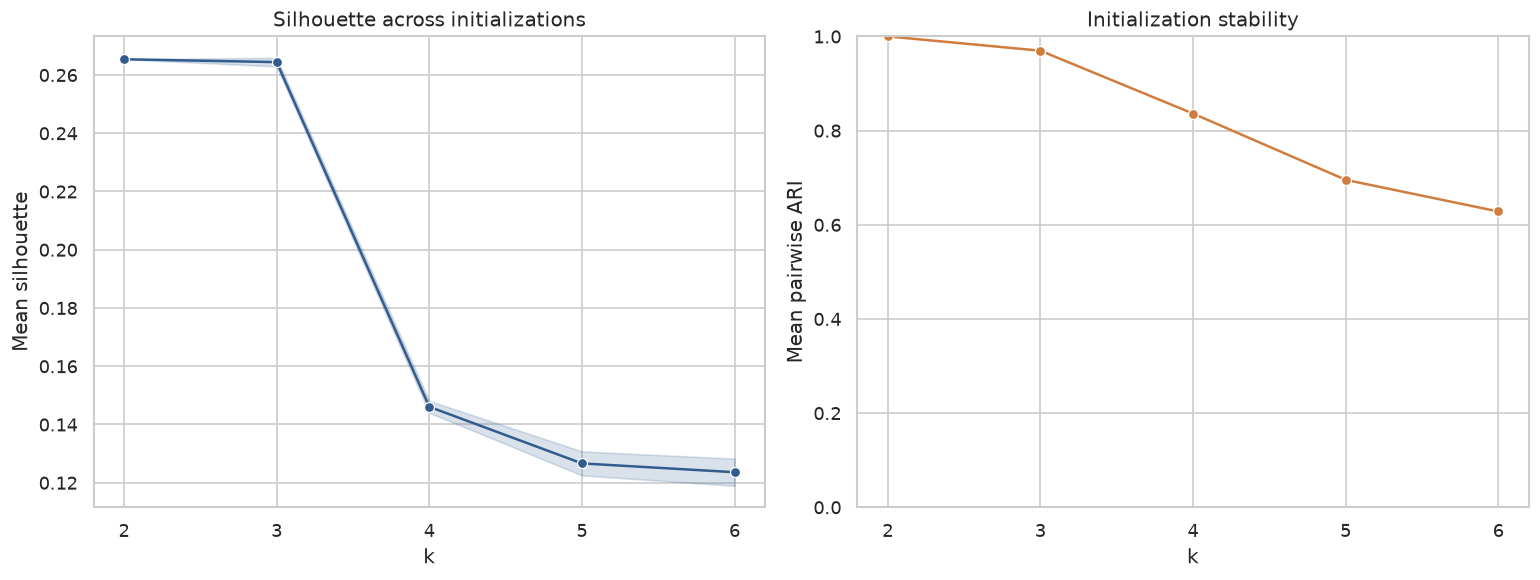

In [3]:
scaler = StandardScaler()
scaled_profiles = scaler.fit_transform(patient_profiles[profile_features])
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
reduced_profiles = pca.fit_transform(scaled_profiles)

selection_rows = []
seed_labels = {}
for k in K_VALUES:
    silhouettes = []
    labels_for_seeds = []
    for seed in range(10):
        model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE + seed)
        labels = model.fit_predict(reduced_profiles)
        silhouettes.append(silhouette_score(reduced_profiles, labels))
        labels_for_seeds.append(labels)
    stability = np.mean([
        adjusted_rand_score(labels_for_seeds[i], labels_for_seeds[j])
        for i, j in combinations(range(len(labels_for_seeds)), 2)
    ])
    seed_labels[k] = labels_for_seeds
    selection_rows.append({
        "k": k,
        "silhouette_mean": np.mean(silhouettes),
        "silhouette_sd": np.std(silhouettes),
        "mean_pairwise_ARI": stability,
    })

selection = pd.DataFrame(selection_rows)
selected_k = int(selection.loc[selection["silhouette_mean"].idxmax(), "k"])
final_kmeans = KMeans(n_clusters=selected_k, n_init=100, random_state=RANDOM_STATE)
cluster_labels = final_kmeans.fit_predict(reduced_profiles)
patient_profiles["cluster"] = cluster_labels + 1

print(f"PCA components retained: {reduced_profiles.shape[1]}")
print(f"Selected k by mean silhouette: {selected_k}")
display(selection.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(data=selection, x="k", y="silhouette_mean", marker="o", ax=axes[0], color="#315c8d")
axes[0].fill_between(
    selection["k"],
    selection["silhouette_mean"] - selection["silhouette_sd"],
    selection["silhouette_mean"] + selection["silhouette_sd"],
    alpha=0.18,
    color="#315c8d",
)
axes[0].set(title="Silhouette across initializations", ylabel="Mean silhouette", xticks=list(K_VALUES))
sns.lineplot(data=selection, x="k", y="mean_pairwise_ARI", marker="o", ax=axes[1], color="#d17c3f")
axes[1].set(title="Initialization stability", ylabel="Mean pairwise ARI", ylim=(0, 1), xticks=list(K_VALUES))
fig.tight_layout()
plt.show()

## Visualize the patient-level groups

The two-dimensional PCA display is for visualization only; K-means is fit in the 90%-variance PCA space, not just the plotted two components.

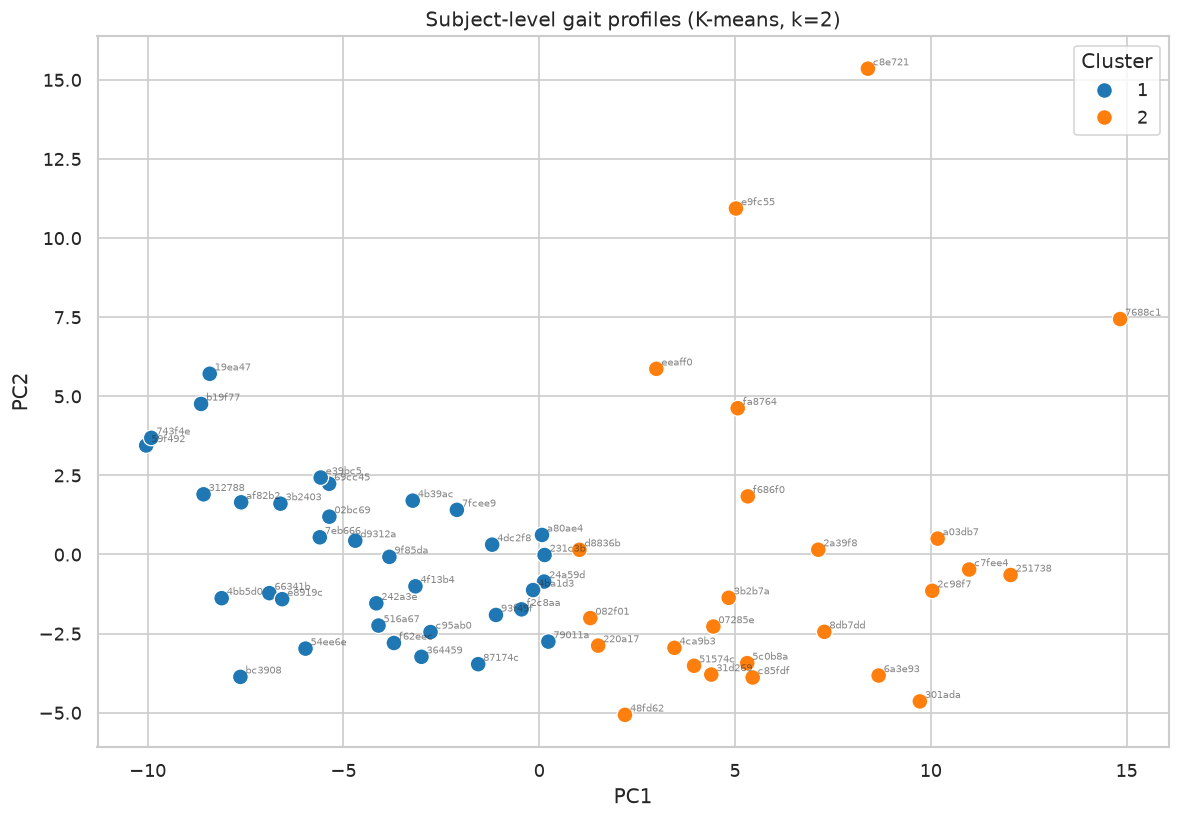

,subjects
cluster,
1,35
2,25


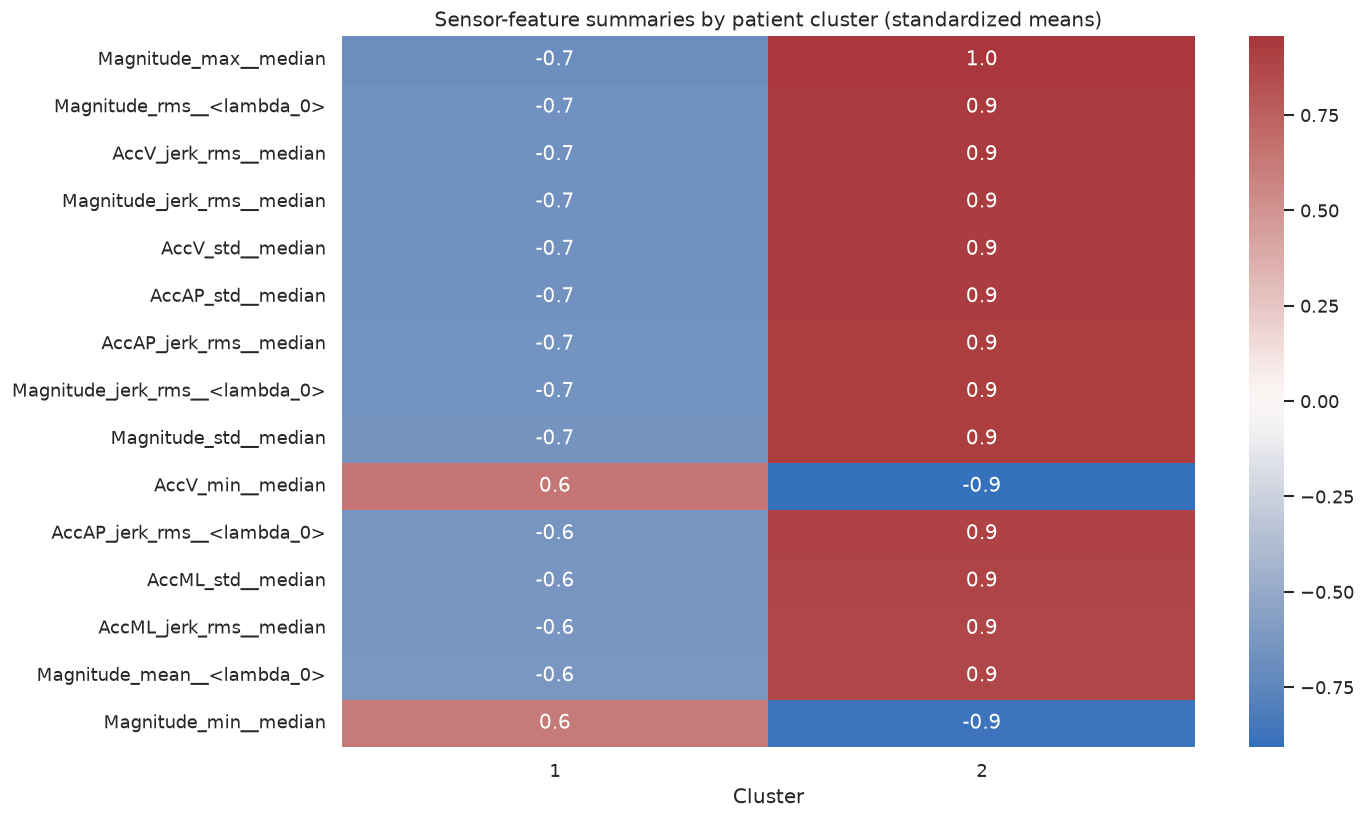

In [4]:
projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaled_profiles)
plot_data = pd.DataFrame({
    "PC1": projection[:, 0],
    "PC2": projection[:, 1],
    "cluster": patient_profiles["cluster"].astype(str),
    "Subject": patient_profiles["Subject"],
})
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=plot_data, x="PC1", y="PC2", hue="cluster", s=90, palette="tab10", ax=ax)
for row in plot_data.itertuples():
    ax.annotate(row.Subject, (row.PC1, row.PC2), fontsize=6, alpha=0.55, xytext=(3, 2), textcoords="offset points")
ax.set_title(f"Subject-level gait profiles (K-means, k={selected_k})")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

cluster_sizes = patient_profiles["cluster"].value_counts().sort_index().rename("subjects").to_frame()
display(cluster_sizes)

scaled_frame = pd.DataFrame(scaled_profiles, columns=profile_features)
scaled_frame["cluster"] = patient_profiles["cluster"].to_numpy()
profile_means = scaled_frame.groupby("cluster").mean()
important_profile_features = profile_means.var(axis=0).nlargest(15).index
plt.figure(figsize=(12, 7))
sns.heatmap(profile_means[important_profile_features].T, cmap="vlag", center=0, annot=True, fmt=".1f")
plt.title("Sensor-feature summaries by patient cluster (standardized means)")
plt.xlabel("Cluster")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Post-hoc clinical comparison

Clinical variables and FoG labels were not used to create the clusters. Compare them after fitting to see whether the sensor-derived groups show exploratory associations. These tests are descriptive and are not a validation of severity staging.

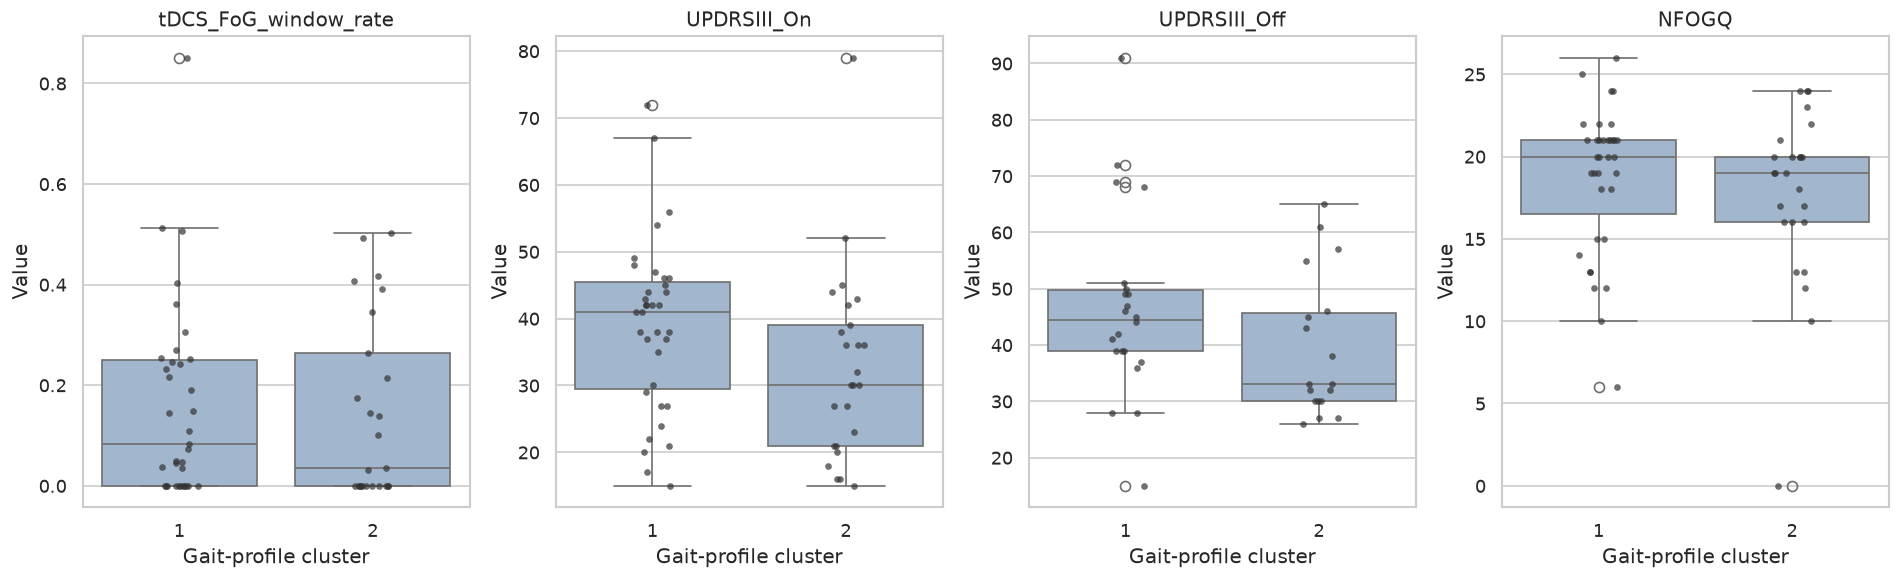

,outcome,kruskal_H,p_value,p_adjusted_BH
0,tDCS_FoG_window_rate,0.3597,0.5487,0.5487
1,UPDRSIII_On,4.7035,0.0301,0.1204
2,UPDRSIII_Off,2.9376,0.0865,0.1731
3,NFOGQ,0.9311,0.3346,0.4461


tDCS_FoG_window_rate               UPDRSIII_On                 \
                       count median   mean       count median    mean   
cluster                                                                 
1                         35  0.083  0.161          35   41.0  39.029   
2                         25  0.036  0.146          25   30.0  32.640   

        UPDRSIII_Off                NFOGQ                 
               count median    mean count median    mean  
cluster                                                   
1                 22   44.5  46.591    35   20.0  18.743  
2                 18   33.0  39.444    25   19.0  17.720

In [5]:
outcomes = ["tDCS_FoG_window_rate", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]
fig, axes = plt.subplots(1, len(outcomes), figsize=(16, 5))
for ax, outcome in zip(axes, outcomes):
    sns.boxplot(data=patient_profiles, x="cluster", y=outcome, color="#9bb7d4", ax=ax)
    sns.stripplot(data=patient_profiles, x="cluster", y=outcome, color="#333333", size=4, alpha=0.7, ax=ax)
    ax.set(title=outcome, xlabel="Gait-profile cluster", ylabel="Value")
fig.tight_layout()
plt.show()

statistical_tests = []
for outcome in outcomes:
    grouped = [
        group[outcome].dropna().to_numpy()
        for _, group in patient_profiles.groupby("cluster")
        if group[outcome].notna().any()
    ]
    statistic, p_value = kruskal(*grouped) if len(grouped) >= 2 else (np.nan, np.nan)
    statistical_tests.append({"outcome": outcome, "kruskal_H": statistic, "p_value": p_value})

test_results = pd.DataFrame(statistical_tests)
valid_p = test_results["p_value"].notna()
p_values = test_results.loc[valid_p, "p_value"].to_numpy()
order = np.argsort(p_values)
ranked = p_values[order]
adjusted = np.minimum.accumulate((ranked * len(ranked) / np.arange(1, len(ranked) + 1))[::-1])[::-1]
adjusted = np.clip(adjusted, 0, 1)
adjusted_original_order = np.empty_like(adjusted)
adjusted_original_order[order] = adjusted
test_results.loc[valid_p, "p_adjusted_BH"] = adjusted_original_order

display(test_results.round(4))
display(patient_profiles.groupby("cluster")[outcomes].agg(["count", "median", "mean"]).round(3))

## Save the trained model and results

The model accepts one row per person containing the same 102 median/IQR sensor-profile features in the saved feature order. New user recordings must first pass through the same window feature extractor as notebook 02, then the same recording-level and patient-level aggregation used here.

In [6]:
final_pipeline = Pipeline([
    ("standardize", scaler),
    ("pca", pca),
    ("kmeans", final_kmeans),
])

assignment_columns = [
    "Subject", "cluster", "window_count", "tDCS_FoG_window_rate",
    "Age", "Sex", "YearsSinceDx", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ",
]
patient_profiles[assignment_columns].to_csv(PROCESSED_DIR / "kmeans_subject_clusters.csv", index=False)
patient_profiles[["Subject"] + profile_features].to_csv(PROCESSED_DIR / "kmeans_subject_sensor_profiles.csv", index=False)
selection.to_csv(PROCESSED_DIR / "kmeans_subject_cluster_selection.csv", index=False)
test_results.to_csv(PROCESSED_DIR / "kmeans_subject_clinical_tests.csv", index=False)

predicted_labels = final_pipeline.predict(patient_profiles[profile_features]) + 1
assert np.array_equal(predicted_labels, patient_profiles["cluster"].to_numpy())

joblib.dump({
    "pipeline": final_pipeline,
    "feature_columns": profile_features,
    "selected_k": selected_k,
    "fit_population": "Kaggle tDCS FoG challenge recordings; subject-level aggregated windows",
    "interpretation": "Exploratory gait-pattern clusters; not clinical severity labels or early-warning probabilities",
}, MODEL_DIR / "kmeans_subject_profile_model.joblib")

summary = {
    "subjects": int(patient_profiles["Subject"].nunique()),
    "recordings": int(windows["Id"].nunique()),
    "window_count": int(len(windows)),
    "raw_sensor_features": int(len(sensor_features)),
    "subject_profile_features": int(len(profile_features)),
    "pca_components": int(reduced_profiles.shape[1]),
    "selected_k": int(selected_k),
    "selected_k_mean_silhouette": float(selection.loc[selection["k"] == selected_k, "silhouette_mean"].iloc[0]),
    "selected_k_mean_pairwise_ari": float(selection.loc[selection["k"] == selected_k, "mean_pairwise_ARI"].iloc[0]),
    "cluster_sizes": {str(key): int(value) for key, value in patient_profiles["cluster"].value_counts().sort_index().items()},
    "data_scope": "tDCS FoG challenge recordings, not daily living data",
}
with open(PROCESSED_DIR / "kmeans_subject_cluster_summary.json", "w") as file:
    json.dump(summary, file, indent=2)

display(pd.Series(summary).to_frame("value"))
print(f"Saved trained subject-profile K-means model to {MODEL_DIR / 'kmeans_subject_profile_model.joblib'}")

,value
subjects,60
recordings,506
window_count,25689
raw_sensor_features,51
subject_profile_features,102
pca_components,16
selected_k,2
selected_k_mean_silhouette,0.265373
selected_k_mean_pairwise_ari,1.0
cluster_sizes,"{'1': 35, '2': 25}"


Saved trained subject-profile K-means model to /home/mathew/Arrakis/da-mp/models/kmeans_subject_profile_model.joblib


## Interpretation and limitations

- The model clusters 60 participants using data from scripted FoG-provoking recordings, not week-long daily-life accelerometer streams.
- The cluster IDs have no inherent order and do not mean mild, moderate, or severe Parkinson’s disease.
- Clinical comparisons are post-hoc, involve a small participant sample, and use subject-level ratings that may represent a different visit.
- A cluster assignment is not an episode forecast. It must not be used to issue “FoG is about to happen” alerts.
- The existing Daily Living dataset is unlabeled for per-timepoint FoG. It can be used for exploratory estimates of daily burden after applying a validated detector, but not as ground truth for severity or early-warning training.
- Treat the output as an exploratory patient-level gait-profile grouping for the microproject.